# 01 — EDA: datasets DAIGT (Detect AI Generated Text)

Objetivos: elegir el dataset canónico de trabajo, entender la composición por
fuente/generador, detectar problemas de calidad, y fundamentar el **diseño de splits**
(la decisión de evaluación más importante del proyecto).

In [1]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"

v2 = pd.read_csv(RAW / "daigt_v2" / "train_v2_drcat_02.csv")
v3a = pd.read_csv(RAW / "daigt_v3" / "train_v3_drcat_01.csv")
v3b = pd.read_csv(RAW / "daigt_v3" / "train_v3_drcat_02.csv")

for name, df in [("v2", v2), ("v3_01", v3a), ("v3_02", v3b)]:
    print(f"{name}: {df.shape[0]:,} filas | cols: {list(df.columns)} | textos nulos: {df.text.isna().sum()}")

v2: 44,868 filas | cols: ['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven'] | textos nulos: 0
v3_01: 65,508 filas | cols: ['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven'] | textos nulos: 148
v3_02: 65,267 filas | cols: ['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven', 'model'] | textos nulos: 0


## ¿Qué archivo usar? Redundancia entre versiones

Comparamos los conjuntos por hash del texto normalizado.

In [2]:
def text_hashes(df):
    return set(df.text.dropna().map(lambda s: hashlib.md5(s.strip().encode()).hexdigest()))

h2, h3b = text_hashes(v2), text_hashes(v3b)
print(f"v2 contenido en v3_02: {len(h2 & h3b):,} / {len(h2):,} ({len(h2 & h3b) / len(h2):.0%})")
print(f"labels v3_02: {v3b.label.value_counts().to_dict()}")

v2 contenido en v3_02: 40,780 / 44,864 (91%)
labels v3_02: {1: 37897, 0: 27370}


**Decisión:** trabajamos solo con `train_v3_drcat_02.csv` (65,267 filas): contiene ~91% de v2,
no tiene textos nulos (v3_01 tiene 148) y es el único con la columna `model`
(familia del generador), que necesitamos para el split OOD. Liberamos memoria del resto.

In [3]:
df = v3b
del v2, v3a, v3b

print(f"sources: {df.source.nunique()} | prompts: {df.prompt_name.nunique()} | familias (model): {df.model.nunique()}")
resumen = df.groupby("model").agg(n=("label", "size"), pct_ai=("label", "mean")).sort_values("n", ascending=False)
resumen

sources: 28 | prompts: 15 | familias (model): 12


,n,pct_ai
model,,
human,27373,0.00011
mistral,13439,1.00000
llama,7490,1.00000
falcon,4536,1.00000
gpt,4161,1.00000
davinci,2099,1.00000
claude,2000,1.00000
palm,1733,1.00000
babbage,698,1.00000


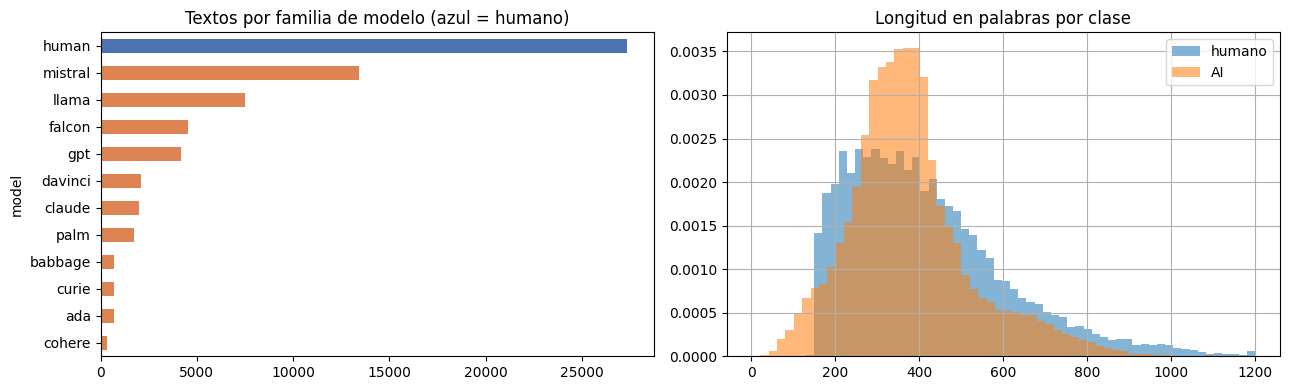

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

resumen.n.plot.barh(ax=axes[0], color=["#4c72b0" if m == "human" else "#dd8452" for m in resumen.index])
axes[0].set_title("Textos por familia de modelo (azul = humano)")
axes[0].invert_yaxis()

df["n_words"] = df.text.str.split().str.len()
for label, name in [(0, "humano"), (1, "AI")]:
    df.loc[df.label == label, "n_words"].clip(upper=1200).hist(bins=60, alpha=0.55, ax=axes[1], label=name, density=True)
axes[1].set_title("Longitud en palabras por clase")
axes[1].legend()
plt.tight_layout()

Las distribuciones de longitud son similares entre clases (humano: mediana 383 palabras;
AI: 361) — bien: la longitud **no** es un atajo trivial para el clasificador.

## Calidad: duplicados y textos degenerados

In [5]:
dups = df.text.map(lambda s: hashlib.md5(s.strip().encode()).hexdigest()).duplicated().sum()
cortos = df[df.n_words < 30]
print(f"duplicados exactos: {dups}")
print(f"textos con <30 palabras: {len(cortos)} (labels: {cortos.label.value_counts().to_dict()})")
print(f"fuentes humanas: {df[df.label == 0].source.value_counts().to_dict()}")

duplicados exactos: 5
textos con <30 palabras: 8 (labels: {1: 8})
fuentes humanas: {'persuade_corpus': 25995, 'train_essays': 1375}


## Conclusiones → diseño de splits

1. **Dataset canónico:** `train_v3_drcat_02.csv` (65,267 textos, 42% humano / 58% AI).
2. **Limpieza mínima:** eliminar 5 duplicados exactos y 8 textos degenerados (<30 palabras).
3. **Riesgo principal:** con un split aleatorio, el modelo ve ejemplos de *todos* los
   generadores en train y las métricas se inflan (memoriza estilos, no detecta "IA").
4. **Diseño elegido — dos niveles de evaluación:**
   - `test_iid`: 15% aleatorio estratificado → mide rendimiento en distribución conocida.
   - `test_ood`: las familias **claude, palm y cohere completas** (~4k textos AI) se excluyen
     de train/val y se evalúan junto a los humanos de `test_iid` → mide generalización a
     generadores nunca vistos, que es el problema real en producción.
   - Familias elegidas por ser arquitecturas distintas entre sí y de tamaño moderado
     (no empobrecen el train, que conserva mistral/llama/falcon/gpt/davinci...).
5. La columna `RDizzl3_seven` (prompts presentes en el test oculto de la competencia) se
   conserva como metadato pero no se usa: nuestro objetivo es el detector general, no el LB.